In [1]:
# required by the esnb notebook framework
import esnb
from esnb import CaseGroup2, NotebookDiagnostic, RequestedVariable, nbtools
from esnb.sites.gfdl import call_dmget, convert_to_momgrid

In [2]:
# required by the diagnostic
import os

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import momgrid
import momlevel as ml
import numpy as np
import pandas as pd
import xarray as xr
import xesmf as xe
from matplotlib.colors import BoundaryNorm, ListedColormap
from momgrid.geoslice import geoslice

# Add the environment variable for MOMGrid weights
os.environ["MOMGRID_WEIGHTS_DIR"] = "/nbhome/jpk/grid_weights"

In [3]:
files =["/archive/Olga.Sergienko/fre_om5/FMS2023.01_om5_20230720/om5_b00_dtcpld1800/gfdl.ncrc5-intel23-prod/pp/ocean_annual/ocean_annual.static.nc","/archive/John.Krasting/fre_om5/FMS2025.02_om5_20250509/om5_b11_nonbouss/gfdl.ncrc6-intel23-prod/pp/ocean_annual/ocean_annual.static.nc"]

In [4]:
call_dmget(files)

dmget: All files are online


In [5]:
om4 = xr.open_dataset("/archive/Olga.Sergienko/fre_om5/FMS2023.01_om5_20230720/om5_b00_dtcpld1800/gfdl.ncrc5-intel23-prod/pp/ocean_annual/ocean_annual.static.nc")
om5 = xr.open_dataset("/archive/John.Krasting/fre_om5/FMS2025.02_om5_20250509/om5_b11_nonbouss/gfdl.ncrc6-intel23-prod/pp/ocean_annual/ocean_annual.static.nc")

In [6]:
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
dsobs_om4 = xr.open_dataset(
            "/archive/gold/datasets/OM4_025/INPUT.JRA.v2019.07.04/salt_restore_JRA.1440x1080.v20190706.nc",
           decode_times=False)
dsobs_om4 = dsobs_om4.rename({"i":"xh","j":"yh","IQ":"xq","JQ":"yq"}) 
dsobs_om5 = xr.open_dataset(
            "/archive/gold/datasets/OM5_025/INPUT/salt_restore_JRA_v20240410.nc",
            decode_times=False)
dsobs_om5 = dsobs_om5.rename({"i":"xh","j":"yh","IQ":"xq","JQ":"yq"}) 
dsobs = {"om4": momgrid.Gridset(dsobs_om4).data,"om5": momgrid.Gridset(dsobs_om5).data}

obs_om5 = dsobs["om5"].sos.mean("time")
obs_om4 = dsobs["om4"].sos.mean("time")

In [7]:
om5_hg= np.maximum(om5.dxt.values,om5.dyt.values)
om4_hg = np.maximum(om4.dxt.values,om4.dyt.values)
om5_hgr = obs_om5.copy()
om5_hgr.values = om5_hg.copy()
om4_hgr = obs_om4.copy()
om4_hgr.values = om4_hg.copy()

In [8]:
reg_settings = {
    "global": {
        "projection": ccrs.Robinson(central_longitude=-160),
        "levels": (-1.0, 1.1, 0.1),
        "xrange": None,
        "yrange": None,
        "hspace": -0.4,
    },
    "arctic": {
        "projection": ccrs.NorthPolarStereo(),
        "levels": (-1.0, 1.125, 0.125),
        "xrange": (-298, 61),
        "yrange": (50.0, 91.0),
        "hspace": 0.2,
    },
    "southern_ocean": {
        "projection": ccrs.SouthPolarStereo(),
        "levels": (-1.0, 1.125, 0.125),
        "xrange": (-300, 60),
        "yrange": (-60.0, -91.0),
        "hspace": 0.2,
    },
}

In [9]:
nbtools.setup_plots()

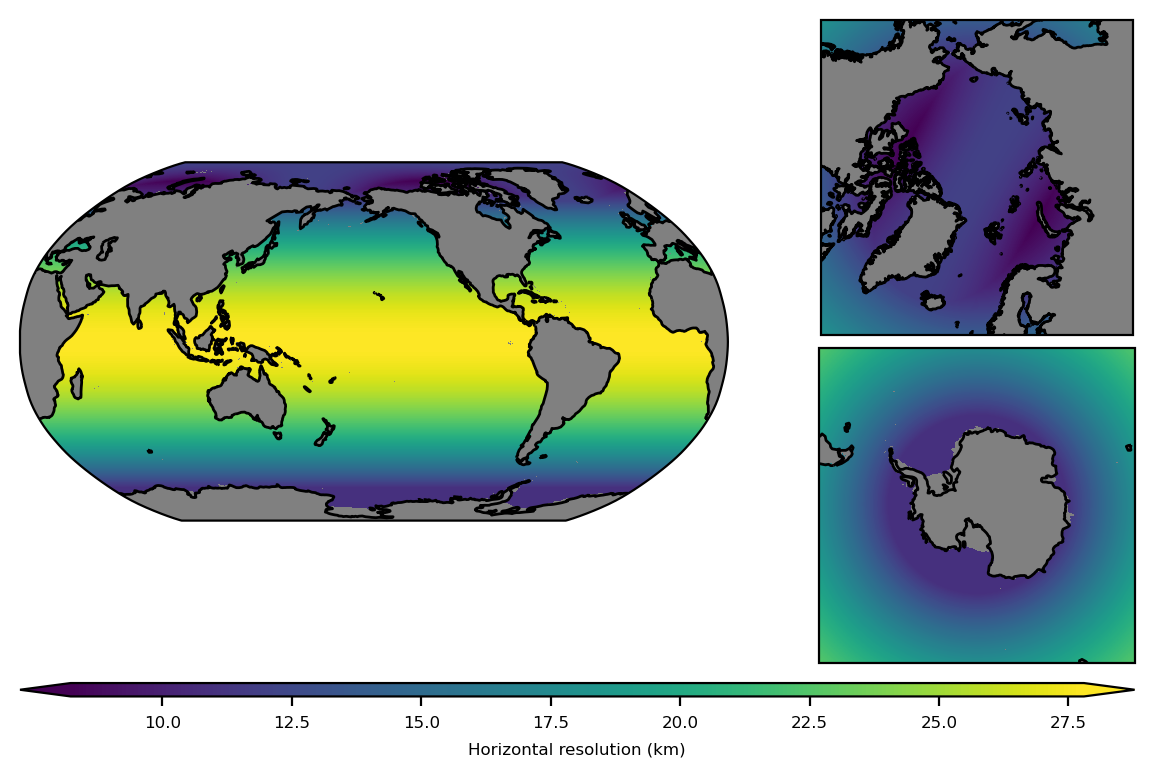

In [10]:
settings = reg_settings["global"]
projection = settings["projection"]
figsize, subplot = nbtools.get_figsize_subplots(3)
fig = plt.figure(figsize=figsize, dpi=200)
# fig=plt.figure(figsize=[8,10])

ax_g = plt.subplot(121,projection=projection,facecolor='grey')
mask = np.where(om5.wet.values>0,1,np.nan)
p_g=plt.pcolormesh(om5_hgr.geolon,om5_hgr.geolat,om5_hgr*mask/1e3,shading='auto',transform=ccrs.PlateCarree())
ax_g.set_facecolor('grey')

# # plt.colorbar(ax=ax,shrink=.65,extend='both') 
ax_g.coastlines()
# # ax.set_extent([-180, 180, -60, -90], ccrs.PlateCarree())
# # ax_g.axis('off')
# plt.tight_layout()

settings = reg_settings["southern_ocean"]
projection = settings["projection"]
ax_so = plt.subplot(224,projection=projection, facecolor='grey')
p=plt.pcolormesh(om5_hgr.geolon,om5_hgr.geolat,om5_hgr*mask/1e3,shading='auto',transform=ccrs.PlateCarree())
ax_so.set_facecolor('grey')
# # plt.colorbar(ax=ax,shrink=.65,extend='both') 
ax_so.coastlines()
ax_so.set_extent([-180, 180, -50, -90], ccrs.PlateCarree())
# ax_so.axis('off')

settings = reg_settings["arctic"]
projection = settings["projection"]
ax_a = plt.subplot(222,projection=projection, facecolor="gray")
p=plt.pcolormesh(om5_hgr.geolon,om5_hgr.geolat,om5_hgr*mask/1e3,shading='auto',transform=ccrs.PlateCarree())
ax_a.coastlines()
# ax_a.set_facecolor('grey')
ax_a.set_extent([-298, 61, 60, 91], ccrs.PlateCarree())
plt.tight_layout()

# ax_a.axis('off')
cbar = nbtools.bottom_colorbar(
            fig, p_g, orientation="horizontal", extend="both"
        )
cbar.set_label(f"Horizontal resolution (km)")

plt.savefig("OM5_hgrid.png",  format='png',bbox_inches='tight',dpi=200)
plt.show()

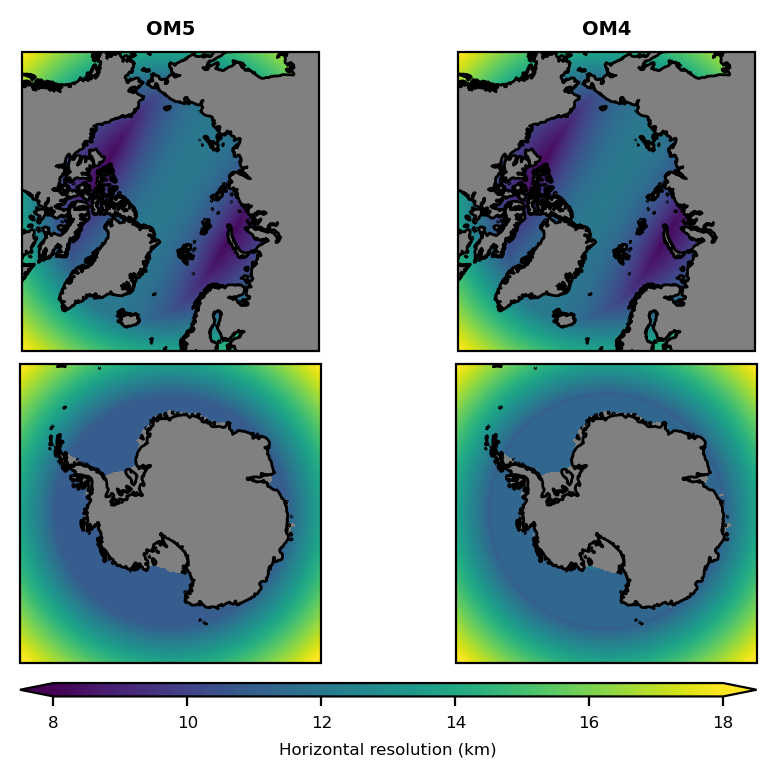

In [11]:
settings = reg_settings["global"]
projection = settings["projection"]
figsize, subplot = nbtools.get_figsize_subplots(3)
fig = plt.figure(figsize=figsize, dpi=200)
# fig=plt.figure(figsize=[8,10])

v_min=8
v_max=18

mask = np.where(om5.wet.values>0,1,np.nan)
settings = reg_settings["southern_ocean"]
projection = settings["projection"]
ax_so = plt.subplot(223,projection=projection, facecolor='grey')
p=plt.pcolormesh(om5_hgr.geolon,om5_hgr.geolat,om5_hgr*mask/1e3,shading='auto',transform=ccrs.PlateCarree(),vmin=v_min,vmax=v_max)
ax_so.set_facecolor('grey')
# # plt.colorbar(ax=ax,shrink=.65,extend='both') 
ax_so.coastlines()
ax_so.set_extent([-180, 180, -60, -90], ccrs.PlateCarree())
# ax_so.axis('off')
plt.tight_layout()


settings = reg_settings["arctic"]
projection = settings["projection"]
ax_a = plt.subplot(221,projection=projection, facecolor="gray")
plt.pcolormesh(om5_hgr.geolon,om5_hgr.geolat,om5_hgr*mask/1e3,shading='auto',transform=ccrs.PlateCarree(),vmin=v_min,vmax=v_max)
ax_a.coastlines()
# ax_a.set_facecolor('grey')
ax_a.set_extent([-298, 61, 60, 91], ccrs.PlateCarree())
plt.tight_layout()
plt.title("OM5",fontweight='demi')

mask = np.where(om4.wet.values>0,1,np.nan)
settings = reg_settings["southern_ocean"]
projection = settings["projection"]
ax_so = plt.subplot(224,projection=projection, facecolor='grey')
p=plt.pcolormesh(om4_hgr.geolon,om4_hgr.geolat,om4_hgr*mask/1e3,shading='auto',transform=ccrs.PlateCarree(),vmin=v_min,vmax=v_max)
ax_so.set_facecolor('grey')
# # plt.colorbar(ax=ax,shrink=.65,extend='both') 
ax_so.coastlines()
ax_so.set_extent([-180, 180, -60, -90], ccrs.PlateCarree())
# ax_so.axis('off')
plt.tight_layout()

settings = reg_settings["arctic"]
projection = settings["projection"]
ax_a = plt.subplot(222,projection=projection, facecolor="gray")
p=plt.pcolormesh(om4_hgr.geolon,om4_hgr.geolat,om4_hgr*mask/1e3,shading='auto',transform=ccrs.PlateCarree(),vmin=v_min,vmax=v_max)
ax_a.coastlines()
# ax_a.set_facecolor('grey')
ax_a.set_extent([-298, 61, 60, 91], ccrs.PlateCarree())
plt.tight_layout()
plt.title("OM4",fontweight='demi')
# ax_a.axis('off')
cbar = nbtools.bottom_colorbar(
            fig, p, orientation="horizontal", extend="both"
        )
cbar.set_label(f"Horizontal resolution (km)")

plt.savefig("OM5_OM4_polar_hgrid.png",  format='png',bbox_inches='tight',dpi=200)
plt.show()